# TP Bi-Partite Graph Edit Distance

## 1) Costs Matrices :

We will use the toy problem again to test the implementations of the different functions.

In [1]:
from GED_lib import graph_loader, path_Dijkstra, draw_pair_graph, make_pair_tree, draw_tree, draw_path
import networkx as nx
import numpy as np
%matplotlib inline

In [2]:
g1_toy = nx.Graph()
g1_toy.add_node(0,node_label = "O")
g1_toy.add_node(1,node_label = "C")
g1_toy.add_node(2,node_label = "O")
g1_toy.add_node(3,node_label = "N")
g1_toy.add_edge(0,1,edge_label = 1)
g1_toy.add_edge(1,2,edge_label = 1)
g1_toy.add_edge(2,3,edge_label = 1)
g1_toy.add_edge(3,1,edge_label = 1)

g2_toy = nx.Graph()
g2_toy.add_node(0,node_label = "N")
g2_toy.add_node(1,node_label = "C")
g2_toy.add_node(2,node_label = "C")
g2_toy.add_edge(0,1,edge_label = 1)
g2_toy.add_edge(1,2,edge_label = 1)

In [3]:
len(g1_toy.nodes()),len(g2_toy.nodes())

(4, 3)

(<Axes: >, <Axes: >)

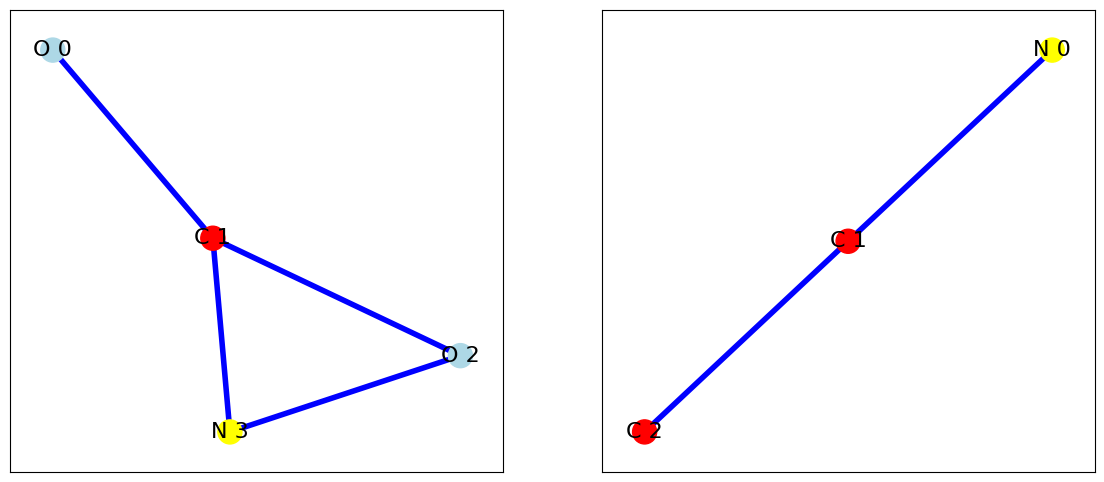

In [4]:
draw_pair_graph(g1_toy,g2_toy)

Here the 3 sets of costs of edits operations are define as follow :

In [ ]:
cost1 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':1,'e_sub':1,'e_del':1}
cost2 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':2,'e_sub':1,'e_del':2}

### a) The C Matrix :

Implement a function that returns the cost matrix $\textbf{C}$ of size (N1+N2,N1+N2), where N1 and N2 are the number of nodes in G1 and G2 respectively.

$$
\textbf{C}_{G_1,G_2}= (c_{i,j}) = \left\{
    \begin{array}{ll}
        cost_{n\_sub(i,j)}  \text{ if } i \leq N_1 \text{ and } j \leq N_2 \\
        cost_{n\_del(i)}  \text{ if } i \leq N_1 \text{ and } j = N_2+i \\
        cost_{n\_ins(j)}  \text{ if } j \leq N_2 \text{ and } i = N_1+j \\
        0 \text{ if } i > N_1 \text{ and } j > N_2 \\
        \infty \text{ otherwise.}
    \end{array}
\right.
$$

An example of output for the toy problem with cost1 (the infinite values are replaced by 100):


    [[  2.,   2.,   2.,   4., 100., 100., 100.],
    [  2.,   0.,   0., 100.,   4., 100., 100.],
    [  2.,   2.,   2., 100., 100.,   4., 100.],
    [  0.,   2.,   2., 100., 100., 100.,   4.],
    [  4., 100., 100.,   0.,   0.,   0.,   0.],
    [100.,   4., 100.,   0.,   0.,   0.,   0.],
    [100., 100.,   4.,   0.,   0.,   0.,   0.]]

In [19]:
def cost_matrix_c(g1,g2,cost):
    inf_value = 100
    
    N1, N2 = (len(g1.nodes()), len(g2.nodes()))
    size = N1 + N2
    c = np.full((size, size), inf_value)
    
    labels1 = nx.get_node_attributes(g1, 'node_label')
    labels2 = nx.get_node_attributes(g2, 'node_label')
    
    for i in range(N1):
        for j in range(N2):
            if labels1[i] == labels2[j]:
                c[i][j] = 0
            else:
                c[i][j] = cost['n_sub']
    for i in range(N1):
        c[i][N2 + i] = cost['n_del']
    
    for j in range(N2):
        c[N1 + j ][j] = cost['n_ins']
        
    for i in range(N1, size):
        for j in range(N2, size):
            c[i][j] = 0
    return c

In [20]:
C_toy = cost_matrix_c(g1_toy,g2_toy,cost1)
C_toy

array([[  2,   2,   2,   4, 100, 100, 100],
       [  2,   0,   0, 100,   4, 100, 100],
       [  2,   2,   2, 100, 100,   4, 100],
       [  0,   2,   2, 100, 100, 100,   4],
       [  4, 100, 100,   0,   0,   0,   0],
       [100,   4, 100,   0,   0,   0,   0],
       [100, 100,   4,   0,   0,   0,   0]])

### b) The edges cost matrices :

Implement a function which takes as arguments: the pair of graphs G1 and G2, n1 and n2 the node identifiers of the current node match, and cost, the set of matching costs.
The function will return a cost matrix of size (d1+d2,d1+d2), where d1 and d2 are the degrees of nodes n1 and n2 respectively.
$$
\text bf{C_edge}_{(G_1,G_2,n1,n2)}= (c\_edge_{i,j}) = \left\{
    \begin{array}{ll}
        cost_{e\_sub(i,j)}  \text{ if } i \leq d_1 \text{ and } j \leq d_2 \\
        cost_{e\_del(i)}  \text{ if } i \leq d_1 \text{ and } j = d_2+i \\
        cost_{e\_ins(j)}  \text{ if } j \leq d_2 \text{ and } i = d_1+j \\
        0 \text{ if } i > d_1 \text{ and } j > d_2 \\
        \infty \text{ otherwise.}
    \end{array}
\right.
$$

In [86]:
def edge_matrix_cost(g1,g2,n1,n2,cost):
    inf_value = 100
    edges_1 = list(g1.edges(n1, data=True))
    edges_2 = list(g2.edges(n2, data=True))
    d1, d2 = len(edges_1), len(edges_2)
    size = d1 + d2
    
    c_edge = np.full((size, size), inf_value, dtype=float)
    #sub
    for i in range(d1):
        for j in range(d2):
            if edges_1[i][2].get('edge_label') == edges_2[j][2].get('edge_label'):
                c_edge[i][j] = 0
            else:
                c_edge[i][j] = cost['e_sub']
    #del
    for i in range(d1):
        c_edge[i][d2 + i] = cost['e_del']
        
    #insertion
    for j in range(d2):
        c_edge[d1 + j][j] = cost['e_ins']

    for i in range(d1, size):
        for j in range(d2, size):
            c_edge[i][j] = 0
            
    return c_edge

In [57]:
edge_matrix_cost(g1_toy, g2_toy, g1_toy.nodes(), g2_toy.nodes(), cost1)

array([[  0.,   0.,   1., 100., 100., 100.],
       [  0.,   0., 100.,   1., 100., 100.],
       [  0.,   0., 100., 100.,   1., 100.],
       [  0.,   0., 100., 100., 100.,   1.],
       [  1., 100.,   0.,   0.,   0.,   0.],
       [100.,   1.,   0.,   0.,   0.,   0.]])

### c) The C* matrix :

Now we want to compute a better fitting cost estimation matrix that takes into account both node and edge operation costs.

To do this we will use the Linear Sum Assignment Problem (LSAP) solver.

By introducing a square cost matrix $\textbf{C}$ of size $N$, which describes the cost of a bipartite matching, and a permutation matrix $\textbf{X} = (x_{i,j}) $ also of size $N$, as follows:

$$
    x_{i,j} = \left\{
    \begin{array}{ll}
        1 \text{ if the row i is matched to the column j} \\
        0 \text{ otherwise }
    \end{array}
    \right.
$$

We can define LSAP solution as :
$$
        LSAP_{cost}({\textbf{C}}) = \min_{\textbf{X}} \sum_{i=1}^{N}\sum_{j=1}^{N}c_{i,j}x_{i,j}\\
         s.t. \sum_{i=1}^{N}x_{i,j} = 1 \\     
           \sum_{j=1}^{N}x_{i,j} = 1
$$    
$$   
           x_{i,j} \in \left\{0,1\right\} \forall(i,j) \in [1,...,N] 
$$

With $ LSAP_{cost}({\textbf{C}})$ the minimum cost of the optimal matching performed on $\textbf{C}$.

You can install a library with the LSAP solver : aka Jonker-Volgenant Algorithm, by using the command :

    pip install lap

The implementation comes from : https://github.com/gatagat/lap , you can also find some documentation about the solver on the git.

Implement a function that returns the cost matrix $\textbf{C}^*$ of size (N1+N2,N1+N2) where N1 and N2 are the number of nodes in G1 and G2 respectively.

$$
\textbf{C*}_{G_1,G_2}(i,j)= \left\{
    \begin{array}{ll}
        \textbf{C}_{G_1,G_2}(i,j) + LSAP_{cost}(\textbf{C_edge}_{(G_1,G_2,i,j)}) \mbox{ if } i \leq N_1 \mbox{ and } j \leq N_2 \\
        \textbf{C}_{G_1,G_2}(i,j) + (deg(i) \times cost_{e\_del(i)})  \mbox{ if } i \leq N_1 \mbox{ and } j = N_2+i \\
        \textbf{C}_{G_1,G_2}(i,j) + (deg(j) \times cost_{e\_ins(j)})  \mbox{ if } j \leq N_2 \mbox{ and } i = N_1+j \\
        0 \mbox{ if } i > N_1 \mbox{ and } j > N_2 \\
        \infty \mbox{ otherwise.}
    \end{array}
\right. 
$$

Example of $\textbf{C}^*$ matrix for the toy problem with the cost1 :

    [[  2.,   3.,   2.,   5., 100., 100., 100.],
    [  4.,   1.,   2., 100.,   7., 100., 100.],
    [  3.,   2.,   3., 100., 100.,   6., 100.],
    [  1.,   2.,   3., 100., 100., 100.,   6.],
    [  5., 100., 100.,   0.,   0.,   0.,   0.],
    [100.,   6., 100.,   0.,   0.,   0.,   0.],
    [100., 100.,   5.,   0.,   0.,   0.,   0.]])

In [87]:
from lap import lapjv
from scipy.optimize import linear_sum_assignment

In [89]:
def cost_matrix_cstar(g1, g2, cost):
    c = cost_matrix_c(g1, g2, cost)
    
    N1 = len(g1.nodes())
    N2 = len(g2.nodes())
    
    cstar = np.copy(c).astype(float)
    for i in range(N1):
        for j in range(N2):
            ce = edge_matrix_cost(g1, g2, i, j, cost)

            row_ind, col_ind = linear_sum_assignment(ce)
            lsap_cost = ce[row_ind, col_ind].sum()
            
            cstar[i][j] += lsap_cost
    for i in range(N1):
        deg_i = g1.degree(i)
        cstar[i][N2 + i] += (deg_i * cost['e_del'])
    for j in range(N2):
        deg_j = g2.degree(j)
        cstar[N1 + j][j] += (deg_j * cost['e_ins'])
        
    return cstar


In [90]:
c_star_toy = cost_matrix_cstar(g1_toy, g2_toy, cost1)
c_star_toy

array([[  2.,   3.,   2.,   5., 100., 100., 100.],
       [  4.,   1.,   2., 100.,   7., 100., 100.],
       [  3.,   2.,   3., 100., 100.,   6., 100.],
       [  1.,   2.,   3., 100., 100., 100.,   6.],
       [  5., 100., 100.,   0.,   0.,   0.,   0.],
       [100.,   6., 100.,   0.,   0.,   0.,   0.],
       [100., 100.,   5.,   0.,   0.,   0.,   0.]])

## 2) Upper Bound :

Now we want to compute an upper bound on the GED from the $\textbf{C}^*$ matrix.

We can do this again using an LSAP solver. As you may have noticed, lapjv() returns the minimum matching cost, but also the indices of the best matching themselves, as follows :

    min_cost,col_ind_bestmatch,raw_ind_bestmatch = lapjv(cost_mat)

You can now copy/paste your cost_path() function from the $\textbf{A}^*$ practical work into the GED_lib library.

Implement a function that takes as input both graphs G1 and G2 and the cost set.

    First compute C* and use lapjv on C*,
    then transform the resulting matching into an edit path,
    then use your cost_path() function on the resulting path.
    Return the path and it's associated cost.


This cost is an upper bound of the GED, why?

Example of output path and UB for the toy problem with cost1 :

    path = [[ 0,  2],[ 1,  1],[ 2, -1],[ 3,  0]]
    UB = 8


In [91]:
def cost_path(g1, g2, path, cost):
    p_cost = 0
    mapped_g1 = [u for u, v in path if u != -1]
    mapped_g2 = [v for u, v in path if v != -1]

    for u, v in path:
        if v == -1: #Suppression
            p_cost += cost['n_del']
        elif u == -1: # Insertion
            p_cost += cost['n_ins']
        else: #Substitution
            if g1.nodes[u]['node_label'] != g2.nodes[v]['node_label']:
                p_cost += cost['n_sub']
        if u != -1 and v != -1:
            for neighbor_u in g1.neighbors(u):
                # Si le voisin est déjà dans le mapping
                for prev_u, prev_v in path:
                    if neighbor_u == prev_u:
                        if prev_v != -1:
                            if not g2.has_edge(v, prev_v):
                                p_cost += cost['e_del'] + cost['e_ins'] # ou e_sub
                        else:
                            p_cost += cost['e_del']
    return p_cost

In [92]:
import GED_lib
def upper_bound(g1, g2, cost):
    C = cost_matrix_cstar(g1, g2, cost)
    row_ind, col_ind = linear_sum_assignment(C)
    
    path = []
    n1 = len(g1.nodes())
    n2 = len(g2.nodes())
    nodes_g1 = list(g1.nodes())
    nodes_g2 = list(g2.nodes())
    
    for r, c in zip(row_ind, col_ind):
        if r < n1 and c < n2:
            # Substitution (u -> v)
            path.append((nodes_g1[r], nodes_g2[c]))
        elif r < n1 and c >= n2:
            # Suppression (u -> epsilon)
            path.append((nodes_g1[r], -1))
        elif r >= n1 and c < n2:
            # Insertion (epsilon -> v)
            path.append((-1, nodes_g2[c]))
    UB = cost_path(g1, g2, path, cost)
    
    return path, UB

In [95]:
path_toy, upper_bound_toy = upper_bound(g1_toy, g2_toy, cost1)
print(f"path_toy: {path_toy}\nupper_bound_toy: {upper_bound_toy}")

path_toy: [(0, -1), (1, 1), (2, 2), (3, 0)]
upper_bound_toy: 11


## 3) Lower Bound :

We will see how to compute a lower bound on the GED. The idea is to underestimate the edge cost matching.
To do this, we will first compute a new matrix cost $\textbf{C}_{LB}$ similar to $\textbf{C}^*$ with a 1/2 factor in the edge cost estimation.

$$
\textbf{C}_{LB}(i,j)= \left\{
    \begin{array}{ll}
        \text bf{C}_{G_1,G_2}(i,j) + LSAP_{cost}(1/2 \times \text bf{C_edge}_{(G_1,G_2,i,j)}) \text{ if } i \leq N_1 \text{ and } j \leq N_2 \\
        \textbf{C}_{G_1,G_2}(i,j) + (1/2 \times deg(i) \times cost_{e\_del(i)})  \text{ if } i \leq N_1 \text{ and } j = N_2+i \\
        \textbf{C}_{G_1,G_2}(i,j) + (1/2 \times deg(j) \times cost_{e\_ins(j)})  \text{ if } j \leq N_2 \text{ and } i = N_1+j \\
        0 \text{ if } i > N_1 \text{ and } j > N_2 \\
        \infty \text{ otherwise.}
    \end{array}
\right. 
$$

Then $LB = LSAP_{cost}(\textbf{C}_{LB})$.

In [96]:
def lower_bound(g1, g2, cost):
    # Construction de la matrice de coûts optimisée (C*)
    C = cost_matrix_cstar(g1, g2, cost)
    
    # Résolution LSAP
    row_ind, col_ind = linear_sum_assignment(C)
    
    # Le coût est la somme des cellules choisies
    LB = C[row_ind, col_ind].sum()
    
    return LB

## 4) A* with BPGED heuristic :

We can now use the lower bound as a heuristic in the A* function.

Modify your lower bound function, to adapt to nodes that are not already matched in the remaining part to explore (partial matching) and insert it as a heuristic in your A* function.

In [100]:
path = './data'
data = graph_loader(path)
data

{'g0': <networkx.classes.graph.Graph at 0x221adba0fb0>,
 'g1': <networkx.classes.graph.Graph at 0x221cd3c2600>,
 'g2': <networkx.classes.graph.Graph at 0x221cd466240>,
 'g3': <networkx.classes.graph.Graph at 0x221cd465dc0>,
 'g4': <networkx.classes.graph.Graph at 0x221cd466450>,
 'g5': <networkx.classes.graph.Graph at 0x221cd466300>}

In [ ]:
df = 

In [101]:
def lower_bound_path(g1, g2, cost, path):
    # 1. Identifier les nœuds déjà traités
    used_u = {u for u, v in path if u != -1}
    used_v = {v for u, v in path if v != -1}
    
    # 2. Extraire les nœuds restants
    remaining_nodes_g1 = [n for n in g1.nodes() if n not in used_u]
    remaining_nodes_g2 = [n for n in g2.nodes() if n not in used_v]
    
    # Si plus rien à traiter, coût restant = 0
    if not remaining_nodes_g1 and not remaining_nodes_g2:
        return 0
    
    # 3. Créer les sous-graphes
    sub_g1 = g1.subgraph(remaining_nodes_g1)
    sub_g2 = g2.subgraph(remaining_nodes_g2)
    
    sub_g1 = nx.convert_node_labels_to_integers(sub_g1, label_attribute='old_label')
    sub_g2 = nx.convert_node_labels_to_integers(sub_g2, label_attribute='old_label')
    
    # 4. Calculer la Lower Bound sur ces sous-graphes
    return lower_bound(sub_g1, sub_g2, cost)

In [ ]:
import heapq

def A_star_BPGED(g1, g2, cost):
    # Heuristique initiale
    h_init = lower_bound(g1, g2, cost)
    
    # File de priorité : (f, g, path)
    open_list = [(h_init, 0, [])]
    
    nodes_g1 = list(g1.nodes())
    nodes_g2 = list(g2.nodes())
    
    # Pour suivre la meilleure solution trouvée (Pruning optionnel mais conseillé)
    best_cost = float('inf')
    
    while open_list:
        f, g, path = heapq.heappop(open_list)
        
        # --- Optimisation : Pruning ---
        # Si f (estimation min) est déjà pire qu'une solution connue, on arrête cette branche
        if f >= best_cost:
            continue
            
        # --- Test de complétude ---
        # On regarde si tous les nœuds de G1 ont été traités
        mapped_g1_count = len([u for u, v in path if u != -1])
        
        if mapped_g1_count == len(nodes_g1):
            # Ajouter les insertions restantes (nœuds de G2 non utilisés)
            used_v = [v for u, v in path if v != -1]
            unused_v = [v for v in nodes_g2 if v not in used_v]
            
            final_path = path + [(-1, v) for v in unused_v]
            final_ged = cost_path(g1, g2, final_path, cost)
            
            # Mise à jour du meilleur coût trouvé
            if final_ged < best_cost:
                best_cost = final_ged
                
            return final_ged, final_path

        # --- Expansion ---
        u = nodes_g1[mapped_g1_count] # Prochain nœud de G1
        used_v_set = {v for u_p, v in path if v != -1}
        
        # 1. Substitutions possibles
        for v in nodes_g2:
            if v not in used_v_set:
                new_path = path + [(u, v)]
                step_g = cost_path(g1, g2, new_path, cost)
                step_h = lower_bound_path(g1, g2, cost, new_path)
                
                new_f = step_g + step_h
                if new_f < best_cost:
                    heapq.heappush(open_list, (new_f, step_g, new_path))
        
        # 2. Suppression de u
        new_path_del = path + [(u, -1)]
        step_g_del = cost_path(g1, g2, new_path_del, cost)
        step_h_del = lower_bound_path(g1, g2, cost, new_path_del)
        
        new_f_del = step_g_del + step_h_del
        if new_f_del < best_cost:
            heapq.heappush(open_list, (new_f_del, step_g_del, new_path_del))

    return None, None

## 5) Experiments :

Now that your tools are ready, you should fill a data frame with the pairs of the 6 graphs in the database.

For each pair, compute the upper bound, the lower bound and the GED of the pairs with BPGED and your A* with the heuristic for cost2.

Verify that LB and UB are a lower and upper bounds of the GED by plotting them on a figure.

Show how fast your A* algorithm has improved with the heuristic.

In [103]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement des données et définition du coût
# Assurez-vous que le chemin "./data" est correct
data = graph_loader("./data") 
cost2 = {'n_ins':4,'n_sub':2,'n_del':4,'e_ins':2,'e_sub':1,'e_del':2}

# Liste des clés triées pour avoir g0, g1, g2...
keys = sorted(data.keys())
results = []

print("Calcul en cours (cela peut prendre un peu de temps)...")

# 2. Boucle sur les paires de graphes
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        g_name1 = keys[i]
        g_name2 = keys[j]
        g1 = data[g_name1]
        g2 = data[g_name2]
        
        # A. Lower Bound (BP-GED)
        start = time.time()
        lb_val = lower_bound(g1, g2, cost2)
        
        # B. Upper Bound (Suboptimal path via BP-GED assignment)
        _, ub_val = upper_bound(g1, g2, cost2)
        
        # C. Exact GED avec A* BPGED
        # On mesure le temps pour voir la performance
        t0 = time.time()
        ged_val, _ = A_star_BPGED(g1, g2, cost2)
        duration = time.time() - t0
        
        # Stockage
        results.append({
            'Pair': f"{g_name1}-{g_name2}",
            'LB': lb_val,
            'GED': ged_val,
            'UB': ub_val,
            'Time (s)': duration
        })
        print(f"Pair {g_name1}-{g_name2}: LB={lb_val}, GED={ged_val}, UB={ub_val} ({duration:.4f}s)")

# Création du DataFrame
df = pd.DataFrame(results)
display(df)

Calcul en cours (cela peut prendre un peu de temps)...
Pair g0-g1: LB=20.0, GED=10, UB=32 (0.0107s)
Pair g0-g2: LB=13.0, GED=8, UB=20 (0.0131s)
Pair g0-g3: LB=5.0, GED=4, UB=18 (0.0040s)
Pair g0-g4: LB=14.0, GED=8, UB=14 (0.0053s)
Pair g0-g5: LB=18.0, GED=6, UB=4 (0.0106s)
Pair g1-g2: LB=15.0, GED=16, UB=24 (0.1354s)
Pair g1-g3: LB=23.0, GED=16, UB=32 (0.0059s)
Pair g1-g4: LB=24.0, GED=18, UB=34 (0.0086s)
Pair g1-g5: LB=16.0, GED=12, UB=24 (0.0150s)
Pair g2-g3: LB=15.0, GED=10, UB=32 (0.0125s)
Pair g2-g4: LB=19.0, GED=16, UB=30 (0.0115s)
Pair g2-g5: LB=10.0, GED=2, UB=18 (0.0066s)
Pair g3-g4: LB=11.0, GED=12, UB=20 (0.0111s)
Pair g3-g5: LB=20.0, GED=8, UB=22 (0.0045s)
Pair g4-g5: LB=20.0, GED=10, UB=18 (0.0046s)


,Pair,LB,GED,UB,Time (s)
0,g0-g1,20.0,10,32,0.010671
1,g0-g2,13.0,8,20,0.013125
2,g0-g3,5.0,4,18,0.004035
3,g0-g4,14.0,8,14,0.005273
4,g0-g5,18.0,6,4,0.010609
5,g1-g2,15.0,16,24,0.135376
6,g1-g3,23.0,16,32,0.005892
7,g1-g4,24.0,18,34,0.008631
8,g1-g5,16.0,12,24,0.015024
9,g2-g3,15.0,10,32,0.012493
